In [1]:
import pandas as pd
from pathlib import Path
from functions import vote_functions

Plusieurs jeux de données sont mobilisés ci-dessous : 
- les résultats des élections municipales
- les listes des municipales, pour récupérer les couleurs politiques de tous les élus municipaux pour les interco
- la liste des présidents d'interco, pour donner une couleur politique aux interco
- la correspondance entre EPCI et communes appartenant à l'interco
- la correspondance entre code Insee et code postal

### Importation données listes municipales 2014

In [2]:
# Dossier contenant uniquement les fichiers à importer
dossier_listes_2014 = Path("/home/onyxia/work/projet3A/data/donnees_electorales/listes_muni_2014")

# Liste de tous les fichiers du dossier
fichiers_2014 = dossier_listes_2014.iterdir()

dfs = []

for f in fichiers_2014:
    ligne_header = vote_functions.detecter_ligne_header(f)
    df = pd.read_excel(f, header=ligne_header)
    df["source"] = f.name  # optionnelle
    dfs.append(df)

df_listes_muni_2014 = pd.concat(dfs, ignore_index=True)

print("Dimensions :", df_listes_muni_2014.shape)

Dimensions : (520074, 16)


On garde uniquement les infos sur la ville, la liste et le numéro dans la liste de chaque personne sur une liste municipale

In [3]:
df_listes_muni_2014.drop(labels = [ "Critère d'export", 'Libellé du département','Libellé commune', 'N° Panneau Liste', 'Code Dépôt',
       'Libellé abrégé liste', 'Libellé Etendu Liste',
       'Sexe', 'Nationalité',
       'Candidat au conseil communautaire', 'source'],axis = 1, inplace=True)

Importation du jeu de données contenant les résultats de toutes les élections (sauf municipales de 2014 qui sont manquantes)

In [5]:
import importlib
import boto3
import os 
from dotenv import load_dotenv
from functions import s3_connexion
from pathlib import Path

# Si le .env est à la racine, remonter d'un niveau (IMPORTANT !!!! ADAPTER selon l'arborescence)
#on met autant de .parent qu'il faut remonter 
dotenv_path = Path().resolve().parent.parent / ".env"
load_dotenv(dotenv_path=dotenv_path, override=True)
s3 = s3_connexion.get_s3()

remote_path = "Elections/candidats_results.txt"
local_path = f"/tmp/{os.path.basename(remote_path)}"    
s3.download_file("mgarbe", remote_path, local_path)
all_elections=pd.read_csv(local_path, sep=";")
all_elections.loc[22340396, 'Binôme'] = all_elections.loc[22160435, 'Binôme']

/tmp/ipykernel_18268/2716464246.py:17: DtypeWarning: Columns (0: Code du département, 1: Code du b.vote, 2: Libellé Abrégé Liste, 3: Libellé Etendu Liste, 4: Nom Tête de Liste, 5: Sexe, 6: Nom, 7: Prénom, 8: Nuance, 9: Binôme, 10: Liste) have mixed types. Specify dtype option on import or set low_memory=False.
  all_elections=pd.read_csv(local_path, sep=";")


In [154]:
muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",
    encoding="latin-1", skiprows=17, header= None)
muni_2014.columns = ['id_tour', 'Code du département', 'Code de la commune', 'Nom de la commune',
'Code du b.vote', 'Inscrits', 'Votants', 'Exprimes', 'num liste', 'Nom', 'Prénom', 'Nuance', 'Voix']
muni_2014['id_tour'] = "t" + muni_2014['id_tour'].astype(str)
print(muni_2014.shape)
print('Nb de communes dans le df', muni_2014['Nom de la commune'].nunique())


#Ici on supprimait tous les candidats de liste sans nuance politique !!! 
#muni_2014 = muni_2014[muni_2014['Nuance'] != "NC"]
print(muni_2014.shape)
print('Nb de communes dans le df', muni_2014['Nom de la commune'].nunique())

/tmp/ipykernel_18268/2898129931.py:1: DtypeWarning: Columns (0: 1, 1: 4) have mixed types. Specify dtype option on import or set low_memory=False.
  muni_2014 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/MN14_Bvot_T1T2.txt", sep=";",


(692029, 13)
Nb de communes dans le df 34221
(692029, 13)
Nb de communes dans le df 34221


In [186]:
muni_2014["Code de la commune"] = muni_2014["Code de la commune"].astype(str).str.zfill(3)
muni_2014["Code du département"] = muni_2014["Code du département"].astype(str).str.zfill(2)

In [187]:
muni_2014.head()

,id_tour,Code du département,Code de la commune,Nom de la commune,Code du b.vote,Inscrits,Votants,Exprimes,num liste,Nom,Prénom,Nuance,Voix,id_brut_miom,id_election,ident_election_ville
0,t1,01,001,L'Abergement-Clémenciat,0001,599,355,341,4,BOUILLOUX,Delphine,NC,324,11_0001,2014_muni_t1,11
1,t1,01,001,L'Abergement-Clémenciat,0001,599,355,341,16,EVALET-TAPONAT,Line,NC,316,11_0001,2014_muni_t1,11
2,t1,01,001,L'Abergement-Clémenciat,0001,599,355,341,3,BERAUD,Zélie,NC,315,11_0001,2014_muni_t1,11
3,t1,01,001,L'Abergement-Clémenciat,0001,599,355,341,14,VACLE,Robert,NC,300,11_0001,2014_muni_t1,11
4,t1,01,001,L'Abergement-Clémenciat,0001,599,355,341,10,MARGUIN,Jean Paul,NC,276,11_0001,2014_muni_t1,11


In [188]:
muni_2014['Code de la commune'].unique()

<ArrowStringArray>
['001', '002', '004', '005', '006', '007', '008', '009', '010', '011',
 ...
 '900', '901', '902', '903', '904', '905', '906', '907', '908', '909']
Length: 908, dtype: str

## Etape initiale : constituer une liste des nuances de tous les candidats

##### Traitement des données des candidats aux départementales, qui ont un format "binome"

In [156]:
elec_binome = all_elections[all_elections["Binôme"].notna()]
liste_elec_binome = elec_binome['id_election'].unique()
election_dep = all_elections[all_elections['id_election'].isin(liste_elec_binome)]
election_dep.drop_duplicates(subset=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], inplace=True)
election_dep = election_dep[["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"]]
election_dep[["candidat1", "candidat2"]] = election_dep["Binôme"].str.split(" et ", expand=True)

# Enlever les titres "M" ou "Mme" au début
election_dep["candidat1"] = election_dep["candidat1"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)
election_dep["candidat2"] = election_dep["candidat2"].str.replace(r"^(M\.|Mme)\s+", "", regex=True)

election_dep[[ "nom1", "prenom1"]] = election_dep["candidat1"].str.split(" ", n=1, expand=True)
election_dep["prenom1"] = election_dep["prenom1"].str.lower()
election_dep[[ "nom2","prenom2"]] = election_dep["candidat2"].str.split(" ", n=1, expand=True)
election_dep["prenom2"] = election_dep["prenom2"].str.lower()

election_dep_long = pd.wide_to_long(election_dep, 
                          stubnames=["prenom", "nom"], 
                          i=["id_election", "id_brut_miom", "Code du département","Nuance", "Binôme"], 
                          j="num_binôme",   # nouveau suffixe qui indiquera 1 ou 2
                          sep="")    # pas de séparateur entre stubname et numéro

# Réinitialiser l'index pour obtenir un DataFrame classique
election_dep_long = election_dep_long.reset_index()
election_dep_long['Nuance'] = election_dep_long['Nuance'].str.replace(r'^BC-', '', regex=True)
election_dep_long.drop(['Binôme', 'num_binôme', 'candidat1', 'candidat2'], axis = 1, inplace= True)

##### Traitement des candidats hors municipales et départementales

In [157]:
election_hors_dep = all_elections[~all_elections['id_election'].isin(liste_elec_binome)]
election_hors_dep_et_muni = election_hors_dep[election_hors_dep["id_election"].str.contains("muni", case=False, na=False)]
election_hors_dep_et_muni = election_hors_dep_et_muni[['id_election', 'id_brut_miom', 'Code du département', 'Nom', 'Prénom', 'Nuance']]

In [158]:
election_dep_long.rename(columns={'prenom': 'Prénom'}, inplace=True)
election_dep_long.rename(columns={'nom': 'Nom'}, inplace=True)
election_dep_long.rename(columns={'Code du département': 'dep'}, inplace=True)
election_hors_dep_et_muni.rename(columns={'Code du département': 'dep'}, inplace=True)
liste_candidats_nuance_hors_muni = pd.concat([election_dep_long, election_hors_dep_et_muni], ignore_index=True)
liste_candidats_nuance_hors_muni['annee'] = liste_candidats_nuance_hors_muni['id_election'].str[:4]
liste_candidats_nuance_hors_muni.head()

,id_election,id_brut_miom,dep,Nuance,Prénom,Nom,annee
0,2021_dpmt_t2,01001_0001,01,UCD,patricia,CHMARA,2021
1,2021_dpmt_t2,01001_0001,01,UCD,patrick,MATHIAS,2021
2,2021_dpmt_t2,01002_0001,01,UG,fabrice,PEREYRON,2021
3,2021_dpmt_t2,01002_0001,01,UG,marie-céline,RAY,2021
4,2021_dpmt_t2,01004_0001,01,UG,fabrice,PEREYRON,2021


### On s'intéresse au score des municipales

In [189]:
muni_2014['id_brut_miom'] = muni_2014['Code du département'].astype(str) + muni_2014['Code de la commune'].astype(str) + "_" + muni_2014['Code du b.vote'].astype(str)
muni_2014['id_election'] = "2014_muni_" + muni_2014['id_tour'].astype(str)
muni_2014['ident_election_ville'] = muni_2014['Code du département'].astype(str) + muni_2014['Code de la commune'].astype(str)

In [190]:
muni_2014['ident_election_ville'].nunique()

36754

In [208]:
all_elections['id_election'].unique()

<ArrowStringArray>
['2019_euro_t1', '2017_legi_t1', '2022_legi_t1', '2021_dpmt_t2',
 '2022_pres_t2', '2020_muni_t2', '2017_pres_t1', '2022_legi_t2',
 '2021_dpmt_t1', '2017_pres_t2', '2022_pres_t1', '2017_legi_t2',
 '2008_muni_t1', '2008_muni_t2', '2024_legi_t2', '2024_legi_t1',
 '2024_euro_t1', '2020_muni_t1', '2015_regi_t2', '2015_regi_t1',
 '2021_regi_t2', '2021_regi_t1', '2002_legi_t1', '2002_legi_t2',
 '2010_regi_t1', '2010_regi_t2', '2004_cant_t1', '2004_cant_t2',
 '2001_cant_t1', '2001_cant_t2', '2008_cant_t1', '2008_cant_t2',
 '1999_euro_t1', '2004_euro_t1', '2004_regi_t1', '2014_euro_t1',
 '2011_cant_t1', '2011_cant_t2', '2007_pres_t1', '2007_pres_t2',
 '2002_pres_t1', '2002_pres_t2', '2015_dpmt_t1', '2015_dpmt_t2',
 '2009_euro_t1', '2007_legi_t1', '2007_legi_t2', '2012_legi_t1',
 '2012_legi_t2', '2012_pres_t1', '2012_pres_t2', '2014_muni_t1',
 '2014_muni_t2']
Length: 53, dtype: str

In [191]:
donnees_restreintes_muni = all_elections[all_elections["id_election"].str.contains("muni", case=False, na=False)]
donnees_restreintes_muni['ident_election_ville'] = donnees_restreintes_muni["id_brut_miom"].str[:5]

#à nouveau, on enlève les candidats où il n'y a pas de nuance politique 
print(donnees_restreintes_muni.shape)
print('Nb de communes dans le df', donnees_restreintes_muni['ident_election_ville'].nunique())
#### ICI on enlevait les candidats sans couleur pour 2008 et 2020
#donnees_restreintes_muni = donnees_restreintes_muni[donnees_restreintes_muni['Nuance'] != 'NC']
print(donnees_restreintes_muni.shape)
print('Nb de communes dans le df', donnees_restreintes_muni['ident_election_ville'].nunique())
#donnees_restreintes_muni = donnees_restreintes_muni[donnees_restreintes_muni['Nuance'] != 'LNC']
print(donnees_restreintes_muni.shape)
print('Nb de communes dans le df', donnees_restreintes_muni['ident_election_ville'].nunique())

(1463530, 19)
Nb de communes dans le df 36814
(1463530, 19)
Nb de communes dans le df 36814
(1463530, 19)
Nb de communes dans le df 36814


In [192]:
donnees_restreintes_muni['Nuance'].value_counts()

Nuance
NC      894059
LDVD     89848
LDVG     80365
LUG      53507
LDIV     42837
LEXG     39627
LSOC     26359
LMAJ     25028
LUD      24667
LFN      24635
LDVC     21253
LNC      20275
LVEC     16429
LRN      12757
LUMP     11134
LCMD     10201
LFG       9074
LLR       8247
LCOM      7807
LREM      7192
LUC       6331
LUDI      5208
LMC       4532
LECO      3890
LAUT      3648
LFI       2951
LREG      2868
LGC       2418
LEXD      2032
LPG       1845
LMDM      1669
LDLF       484
LGJ        235
LRDG       116
2            2
Name: count, dtype: int64

In [193]:
donnees_restreintes_muni['Nuance'].unique()

<ArrowStringArray>
[  'NC', 'LDIV', 'LDVC', 'LDVD',  'LNC', 'LDVG',  'LLR', 'LEXD',  'LRN',
 'LECO',  'LUG', 'LSOC',  'LUD', 'LCOM', 'LREM', 'LVEC', 'LMDM',  'LUC',
 'LEXG', 'LUDI',  'LFI', 'LREG', 'LDLF',  'LGJ', 'LAUT', 'LMAJ',  'LGC',
  'LMC', 'LCMD',  'LFN', 'LRDG',    '2', 'LUMP',  'LFG',  'LPG']
Length: 35, dtype: str

In [194]:
print('Nb de communes dans le df', donnees_restreintes_muni['ident_election_ville'].nunique())

Nb de communes dans le df 36814


On fusionne toutes les données d'élections municipales 

In [206]:
donnees_restreintes_muni['id_election'].unique()

<ArrowStringArray>
['2020_muni_t2', '2008_muni_t1', '2008_muni_t2', '2020_muni_t1',
 '2014_muni_t1', '2014_muni_t2']
Length: 6, dtype: str

In [209]:
#restes d'une vieille concaténation
donnees_muni = donnees_restreintes_muni

In [210]:
donnees_muni.tail(50)

,id_election,id_brut_miom,Code du département,Code de la commune,Code du b.vote,N°Panneau,Libellé Abrégé Liste,Libellé Etendu Liste,Nom Tête de Liste,Voix,% Voix/Ins,% Voix/Exp,Sexe,Nom,Prénom,Nuance,Binôme,Liste,ident_election_ville
27097111,2014_muni_t2,ZP057_0006,ZP,57,6,38.0,NaN,NaN,NaN,38.0,54.29,NaN,NaN,BRUNEAU,Ame,NC,NaN,NaN,ZP057
27097112,2014_muni_t2,ZP057_0006,ZP,57,6,31.0,NaN,NaN,NaN,38.0,54.29,NaN,NaN,KEUVAHANA,Patricia,NC,NaN,NaN,ZP057
27097113,2014_muni_t2,ZP057_0006,ZP,57,6,34.0,NaN,NaN,NaN,38.0,54.29,NaN,NaN,HIKUTINI EPOUSE TEIKITUTO,Rosalie,NC,NaN,NaN,ZP057
27097114,2014_muni_t2,ZP057_0006,ZP,57,6,39.0,NaN,NaN,NaN,40.0,57.14,NaN,NaN,TAHIATOHUIPOKO,Pierre,NC,NaN,NaN,ZP057
27097115,2014_muni_t2,ZP057_0006,ZP,57,6,42.0,NaN,NaN,NaN,38.0,54.29,NaN,NaN,TEIKIEHUUPOKO,Pierre,NC,NaN,NaN,ZP057
27097116,2014_muni_t2,ZP057_0006,ZP,57,6,6.0,NaN,NaN,NaN,25.0,35.71,NaN,NaN,TEIKITUTOUA,Linda,NC,NaN,NaN,ZP057
27097117,2014_muni_t2,ZP057_0006,ZP,57,6,9.0,NaN,NaN,NaN,0.0,0.00,NaN,NaN,DEHEURLE,Patrice,NC,NaN,NaN,ZP057
27097118,2014_muni_t2,ZP057_0006,ZP,57,6,12.0,NaN,NaN,NaN,24.0,34.29,NaN,NaN,RAGUSA,Pierre,NC,NaN,NaN,ZP057
27097119,2014_muni_t2,ZP057_0006,ZP,57,6,13.0,NaN,NaN,NaN,0.0,0.00,NaN,NaN,HOKAUPOKO,Moeaki,NC,NaN,NaN,ZP057
27097120,2014_muni_t2,ZP057_0006,ZP,57,6,28.0,NaN,NaN,NaN,0.0,0.00,NaN,NaN,HITUPUTOKA,Armand,NC,NaN,NaN,ZP057


In [212]:
donnees_muni[donnees_muni['ident_election_ville'] == '78686'].drop(['N°Panneau','Nom Tête de Liste',
       'Libellé Abrégé Liste', 'Libellé Etendu Liste', 'Binôme'], axis = 1)

,id_election,id_brut_miom,Code du département,Code de la commune,Code du b.vote,Voix,% Voix/Ins,% Voix/Exp,Sexe,Nom,Prénom,Nuance,Liste,ident_election_ville
6644566,2008_muni_t1,78686_0001,78,686,0001,120.0,12.63,NaN,M,MARGUERIT,Philippe,LSOC,NaN,78686
6644567,2008_muni_t1,78686_0002,78,686,0002,120.0,13.26,NaN,M,MARGUERIT,Philippe,LSOC,NaN,78686
6644568,2008_muni_t1,78686_0003,78,686,0003,122.0,12.83,NaN,M,MARGUERIT,Philippe,LSOC,NaN,78686
6644569,2008_muni_t1,78686_0004,78,686,0004,125.0,15.24,NaN,M,MARGUERIT,Philippe,LSOC,NaN,78686
6644570,2008_muni_t1,78686_0005,78,686,0005,124.0,13.75,NaN,M,MARGUERIT,Philippe,LSOC,NaN,78686
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26890180,2014_muni_t1,78686_0011,78,686,11,133.0,15.25,NaN,NaN,BOUFFARTIGUE,Julien,LSOC,NaN,78686
26890181,2014_muni_t1,78686_0011,78,686,11,245.0,28.10,NaN,NaN,LEBRUN,Olivier,LUD,NaN,78686
26890182,2014_muni_t1,78686_0012,78,686,12,94.0,9.01,NaN,NaN,COQUEREL,Jérôme,LDIV,NaN,78686
26890183,2014_muni_t1,78686_0012,78,686,12,132.0,12.66,NaN,NaN,BOUFFARTIGUE,Julien,LSOC,NaN,78686


In [213]:
# ---- Étape 1 : calcul des voix totales par élection et ville ----
voix_totales = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville"], as_index=False)
    .agg(voix_total_ville_elec=("Voix", "sum"))
)

In [215]:
print(voix_totales[voix_totales['id_election'] == '2014_muni_t1'].shape)
print(voix_totales[voix_totales['id_election'] == '2014_muni_t2'].shape)
print(voix_totales[voix_totales['id_election'] == '2020_muni_t1'].shape)
print(voix_totales[voix_totales['id_election'] == '2020_muni_t2'].shape)

(36697, 3)
(6513, 3)
(34917, 3)
(4579, 3)


In [216]:
voix_totales.tail()

,id_election,ident_election_ville,voix_total_ville_elec
86197,2020_muni_t2,ZP739,158.0
86198,2020_muni_t2,ZP742,2793.0
86199,2020_muni_t2,ZP743,3255.0
86200,2020_muni_t2,ZP755,2221.0
86201,2020_muni_t2,ZP758,2752.0


In [217]:
# ---- Étape 2 : calcul des voix par candidat ----
donnees_muni_long = (
    donnees_muni
    .groupby(["id_election", "ident_election_ville", "Nom", "Prénom", "Nuance"], as_index=False)
    .agg(voix_totales_candidat=("Voix", "sum"))
    .merge(voix_totales, on=["id_election", "ident_election_ville"], how="left")
    .assign(voix_pct=lambda d: d["voix_totales_candidat"] / d["voix_total_ville_elec"] * 100)
    .sort_values(["id_election", "ident_election_ville", "voix_pct"], ascending=[True, True, False])
)

In [227]:
# ---- Étape 3 : classement des deux premiers ----
donnees_muni_wide = (
    donnees_muni_long
    .assign(rang=lambda d: d.groupby(["id_election", "ident_election_ville"]).cumcount() + 1)
    .query("rang <= 2")
    .pivot(index=["id_election", "ident_election_ville"],
           columns="rang",
           values=["Prénom", "Nom", "Nuance","voix_pct"])
)

# Aplatir les noms de colonnes hiérarchiques comme "rang1_Prénom"
donnees_muni_wide.columns = [
    f"rang{r}_{v}" for v, r in donnees_muni_wide.columns
]
donnees_muni_wide = donnees_muni_wide.reset_index()


In [228]:
donnees_muni_wide.tail()

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct
86197,2020_muni_t2,ZP739,Euloge,Tepui Joachim,VARUATUA,TEVAATUA,NC,NC,46.202532,29.746835
86198,2020_muni_t2,ZP742,Tepepe,Leonne,TAIEMOEARO,TEARA,NC,NC,5.442177,5.442177
86199,2020_muni_t2,ZP743,Théodore Taputuura,Artigas,IOANE,HATITIO,NC,NC,3.993856,3.778802
86200,2020_muni_t2,ZP755,Tevahineheipua,Béatrice,BRANDER,TEHUMU-TEFA,NC,NC,5.312922,4.81765
86201,2020_muni_t2,ZP758,Matahi,Sylviane,BROTHERSON,TEROOATEA,LDVD,LDVD,50.181686,49.818314


In [222]:
print(donnees_muni_wide[(donnees_muni_wide['id_election'] == "2014_muni_t2")
]['rang1_Nuance'].value_counts())
print(donnees_muni_wide.head())

rang1_Nuance
NC      4773
LDVD     574
LDVG     314
LDIV     266
LUD      159
LUG      145
LSOC     104
LUMP      97
LUDI      33
LFG       10
LCOM      10
LFN        9
LMDM       7
LUC        6
LVEC       3
LEXD       2
LPG        1
Name: count, dtype: int64
    id_election ident_election_ville rang1_Prénom rang2_Prénom rang1_Nom  \
0  2008_muni_t1                01004      Josiane     Sandrine  EXPOSITO   
1  2008_muni_t1                01014      Liliane       Michel  MAISSIAT   
2  2008_muni_t1                01033        Régis          Guy     PETIT   
3  2008_muni_t1                01034  Jean-Claude    Jean-Marc   TRAVERS   
4  2008_muni_t1                01043       Michel     Isabelle     NICOD   

    rang2_Nom rang1_Nuance rang2_Nuance rang1_voix_pct rang2_voix_pct  
0  CASTELLANO          LUG         LDVD      31.390449      31.062734  
1    GAUTHIER         LMAJ         LDVD       78.73701       21.26299  
2   LARMANJAT         LMAJ         LSOC      58.224883      41.7751

In [ ]:
# ---- Étape 5 : extraire les variables election / tour ----
#on supprime le premier tour s'il existe un second tour pour cette ville et cette élection
g = donnees_muni_wide.assign(
    election=lambda d: d["id_election"].str[:9],
    tour=lambda d: d["id_election"].str[10:12]
)

has_t2 = g.groupby(["election","ident_election_ville"])["tour"].transform(lambda x: (x=="t2").any())

donnees_muni_wide = g[(~has_t2) | (g["tour"]=="t2")]

In [ ]:
#ci-dessous ancienne version du code ci dessus
# donnees_muni_wide = (
#     donnees_muni_wide
#     .assign(
#         election=lambda d: d["id_election"].str[:9],
#         tour=lambda d: d["id_election"].str[10:12]
#     )
#     .groupby(["election", "ident_election_ville"], group_keys=False)
#     .apply(lambda g: g[g["tour"] != "t1"] if "t2" in g["tour"].values else g)
# )

In [230]:
donnees_muni_wide.tail(30)

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour
86172,2020_muni_t2,ZN811,Thierry,Apangou,GOWECEE,GOROMIDO,LREG,LREG,38.937775,33.940918,2020_muni,t2
86173,2020_muni_t2,ZN812,Wilfrid,Marie Hyacinta,WEISS,SANTINO,LDIV,LNC,51.086957,48.913043,2020_muni,t2
86174,2020_muni_t2,ZN813,Nicolas,Marielle,METZDORF,KELETAONA,LNC,LDVC,46.859536,36.467453,2020_muni,t2
86175,2020_muni_t2,ZN815,Maryline,Joseph,SINEWAMI,WAIKEDRE,LREG,LREG,50.552098,39.289299,2020_muni,t2
86176,2020_muni_t2,ZN817,Eddie,Nina,LECOURIEUX,JULIÉ,LLR,LDVC,46.048632,28.703141,2020_muni,t2
86177,2020_muni_t2,ZN819,Barnabe,Yohann,PEBOU HAMENE,SCHOUENE,LNC,LNC,36.961286,24.616508,2020_muni,t2
86178,2020_muni_t2,ZN820,Maurice,Mickael,TILLEWA,WANAKAHME,LNC,LNC,49.841158,21.602541,2020_muni,t2
86179,2020_muni_t2,ZN821,Willy,Milakulo,GATUHAU,TUKUMULI,LDVD,LNC,49.899875,30.137672,2020_muni,t2
86180,2020_muni_t2,ZN822,Paul Tyaou,"Didier, Kaehene",NEAOUTYINE,POIDYALIWANE,LDVG,LREG,51.677852,31.282625,2020_muni,t2
86181,2020_muni_t2,ZN824,Florentin,Rodrigue,DEDANE,TIAVOUANE,LNC,LNC,42.243437,23.54813,2020_muni,t2


In [231]:
donnees_muni_wide[(donnees_muni_wide['id_election'] == "2014_muni_t2")
]['rang1_Nuance'].value_counts()

rang1_Nuance
NC      4773
LDVD     574
LDVG     314
LDIV     266
LUD      159
LUG      145
LSOC     104
LUMP      97
LUDI      33
LFG       10
LCOM      10
LFN        9
LMDM       7
LUC        6
LVEC       3
LEXD       2
LPG        1
Name: count, dtype: int64

In [232]:
donnees_muni_wide.head()

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour
1,2008_muni_t1,01014,Liliane,Michel,MAISSIAT,GAUTHIER,LMAJ,LDVD,78.73701,21.26299,2008_muni,t1
2,2008_muni_t1,01033,Régis,Guy,PETIT,LARMANJAT,LMAJ,LSOC,58.224883,41.775117,2008_muni,t1
5,2008_muni_t1,01053,Jean-François,Christophe,DEBAT,FEILLENS,LSOC,LMAJ,55.371775,34.802731,2008_muni,t1
7,2008_muni_t1,01142,Bernard,Bernard,SIMPLEX,LOBIETTI,LDVD,LMAJ,58.760951,41.239049,2008_muni,t1
8,2008_muni_t1,01143,Etienne,NaN,BLANC,NaN,LMAJ,NaN,100.0,NaN,2008_muni,t1


In [234]:
#on prépare la suite en créant un fichier listant les têtes de liste des municipales et leur couleur politique
liste_candidats_nuance_muni = (
                    donnees_muni_long
                    .assign(annee = lambda d : d["id_election"].str[0:4])
                    .assign(dep = lambda d : d["ident_election_ville"].str[0:2])
                    .loc[:, ["id_election", "ident_election_ville","annee","dep", "Nom", "Prénom", "Nuance"]]
)
liste_candidats_nuance_muni.tail(20)


,id_election,ident_election_ville,annee,dep,Nom,Prénom,Nuance
923734,2020_muni_t2,ZP755,2020,ZP,MAIRIHAU,"Jean, Teariki",NC
923722,2020_muni_t2,ZP755,2020,ZP,BRANDER,Wini,NC
923728,2020_muni_t2,ZP755,2020,ZP,FARIKI,Parae,NC
923732,2020_muni_t2,ZP755,2020,ZP,MAI,Purotu,NC
923741,2020_muni_t2,ZP755,2020,ZP,TAUMIHAU,Katupu,NC
923733,2020_muni_t2,ZP755,2020,ZP,MAI ÉPOUSE TEHUMU,Elise,NC
923723,2020_muni_t2,ZP755,2020,ZP,FAAREOITI,Heimiti,NC
923752,2020_muni_t2,ZP755,2020,ZP,TERAKAUHAU,Loana,NC
923740,2020_muni_t2,ZP755,2020,ZP,TAMARII-PENI,Teumere,NC
923745,2020_muni_t2,ZP755,2020,ZP,TEAUROA,Wilna,NC


In [235]:
liste_candidats_nuance_muni[(liste_candidats_nuance_muni['annee'] == "2014")&
                                (liste_candidats_nuance_muni['id_election'] == "2014_muni_t2")
]['ident_election_ville'].describe()

count     66786
unique     6513
top       ZP029
freq        153
Name: ident_election_ville, dtype: object

Retour aux listes des municipales

In [236]:
df_listes_muni_2014.head()
df_listes_muni_2014['ident_election_ville'] = df_listes_muni_2014['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2014['Code commune'].astype(str).str.zfill(3)


In [237]:
# Harmonisation de sécurité (évite erreurs minuscules/majuscules/espaces)
for col in ["ident_election_ville", "Nom", "Prénom"]:
    df_listes_muni_2014[col] = df_listes_muni_2014[col].astype(str).str.strip().str.upper()
    liste_candidats_nuance_muni[col] = liste_candidats_nuance_muni[col].astype(str).str.strip().str.upper()

# On récupère uniquement les têtes (ordre = 1)
tetes_listes_ss_nuance_2014 = df_listes_muni_2014[df_listes_muni_2014['N° du candidat dans la liste'] == 1].copy()
#tetes_listes_ss_nuance.drop(tetes_listes_ss_nuance[tetes_listes_ss_nuance["commune"] == "PARIS"].index)
tetes_listes_ss_nuance_2014.drop(labels = ['N° du candidat dans la liste', 'Code du département', 'Code commune'],
 axis = 1, inplace=True)
tetes_listes_ss_nuance_2014['annee'] = '2014'

In [238]:
liste_candidats_nuance_muni_2014 = liste_candidats_nuance_muni.drop(liste_candidats_nuance_muni[liste_candidats_nuance_muni["id_election"] == "2014_muni_t2"].index,
                                axis = 0)

In [239]:
# On ajoute leur nuance depuis la base des nuances
tetes_listes_avec_nuance_2014 = tetes_listes_ss_nuance_2014.merge(
    liste_candidats_nuance_muni_2014[["ident_election_ville", "Nom", "Prénom", "Nuance", "annee"]],
    on=["ident_election_ville", "Nom", "Prénom", "annee"],
    how="left"
)

In [240]:
# On garde uniquement commune + tête + nuance
tetes_listes_avec_nuance_2014 = tetes_listes_avec_nuance_2014[[
    "ident_election_ville",
    "Nom",
    "Prénom",
    "Nuance"
]]

#Pour chaque TETE DE LISTE, on associe sa nuance
liste_candidats_muni_2014_avec_nuance = df_listes_muni_2014.merge(
    tetes_listes_avec_nuance_2014,
    on=["ident_election_ville", "Nom", "Prénom"],
    how="left"
)

print(liste_candidats_muni_2014_avec_nuance.head(40))
#print("\nRépartition des nuances :")
#print(df_listes_muni_2014_avec_nuance["Nuance"].value_counts(dropna=False))


   Code du département Code commune  N° du candidat dans la liste  \
0                   25            4                             1   
1                   25            4                             2   
2                   25            4                             3   
3                   25            4                             4   
4                   25            4                             5   
5                   25            4                             6   
6                   25            4                             7   
7                   25            4                             8   
8                   25            4                             9   
9                   25            4                            10   
10                  25            4                            11   
11                  25            4                            12   
12                  25            4                            13   
13                  25            

In [241]:
#on répercute à l'ensemble des colistiers la nuance de la tête de liste
liste_candidats_muni_2014_avec_nuance["Nuance"] = liste_candidats_muni_2014_avec_nuance["Nuance"].ffill()
liste_candidats_muni_2014_avec_nuance['dep'] = liste_candidats_muni_2014_avec_nuance['Code du département'].astype(str).str.zfill(2) 
liste_candidats_muni_2014_avec_nuance.head(40)
liste_candidats_muni_2014_avec_nuance.drop(labels=['N° du candidat dans la liste', 'Code commune', 'Code du département'], axis = 1, inplace=True)

In [242]:
liste_candidats_muni_2014_avec_nuance['annee'] = "2014"
liste_candidats_muni_2014_avec_nuance.head()

,Nom,Prénom,ident_election_ville,Nuance,dep,annee
0,MARCHETTI,PASCAL,25004,LDVD,25,2014
1,RACINE,ISABELLE,25004,LDVD,25,2014
2,CROCE,NORBERT,25004,LDVD,25,2014
3,TOURMAN,JOSIANE,25004,LDVD,25,2014
4,BENCHETRIT,JEAN-CLAUDE,25004,LDVD,25,2014


#### dernière information à récupérer : liste des élections municipales de 2020

In [243]:
df_listes_muni_2020 = pd.read_excel("/home/onyxia/work/projet3A/data/donnees_electorales/listes_muni_2020/livre-des-listes-et-candidats_2020.xlsx",
                                skiprows = 2)
df_listes_muni_2020 = df_listes_muni_2020.rename(columns={"N° candidat": "N° du candidat dans la liste",
                        'Prénom candidat':'Prénom',
                        'Nom candidat' : 'Nom',
                        'Nuance Liste' : 'Nuance'})
df_listes_muni_2020['annee'] = "2020"

In [244]:
df_listes_muni_2020['ident_election_ville'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) + df_listes_muni_2020['Code commune'].astype(str).str.zfill(3)
df_listes_muni_2020['dep'] = df_listes_muni_2020['Code du département'].astype(str).str.zfill(2) 
df_listes_muni_2020.drop(labels = ['Libellé du département', 'Code commune', 'Libellé commune',
       'N° Panneau Liste', 'Libellé abrégé liste', 'Libellé Etendu Liste', 'Code du département',
       'N° du candidat dans la liste', 'Sexe candidat', 'Nationalité', 'Candidat au conseil communautaire'],
       axis = 1, inplace= True)

## Fusion de toutes les informations sur les nuances politiques

In [245]:
from functions import vote_functions
liste_candidats_nuance = pd.concat([liste_candidats_nuance_hors_muni,liste_candidats_nuance_muni,
liste_candidats_muni_2014_avec_nuance,df_listes_muni_2020], ignore_index=True)
liste_candidats_nuance.head()
liste_candidats_nuance['prenom'] =liste_candidats_nuance['Prénom'].str.lower().apply(vote_functions.simplifier_prenom)
liste_candidats_nuance['nom'] =liste_candidats_nuance['Nom'].str.lower().apply(vote_functions.simplifier_prenom)
liste_candidats_nuance.dropna(subset=['prenom'], inplace=True)
liste_candidats_nuance.drop(columns=["id_election","id_brut_miom","ident_election_ville","Prénom", "Nom"], inplace=True)
liste_candidats_nuance.drop_duplicates(inplace=True)


Importation des données des intercommunalités

In [246]:
#grp_2013 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/interco/Liste_des_groupements_en_2013.csv", encoding="latin-1", sep = ";")
grp_2019 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/interco/Liste_des_groupements_en_2019.csv", encoding="latin-1", sep = ";")
grp_2025 = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/interco/Liste_des_groupements_en_2024.csv", encoding="latin-1", sep = ";")
#grp_2013['annee'] = "2008"
grp_2019['annee'] = "2014"
grp_2025['annee'] = "2020"

liste_grps = [grp_2019, grp_2025] #grp_2013,

for df in liste_grps:
    df['Nom Président'] = df['Nom Président'].str.lower().apply(vote_functions.simplifier_prenom)
    df['prenom'] = df['Prénom Président'].str.lower().apply(vote_functions.simplifier_prenom)
    df['dep'] = df["Département siège"].str[:2]
    df['annee'] = df['annee'].astype(int)
    df['dep'] = df['dep'].astype(str)
    df = df.sort_values("annee")



In [247]:
liste_candidats_nuance['annee'] = liste_candidats_nuance['annee'].astype(int)
liste_candidats_nuance['dep'] = liste_candidats_nuance['dep'].astype(str)
liste_candidats_nuance = liste_candidats_nuance.sort_values("annee")

In [248]:
#on fusionne notre groupement entre les présidents des interco et nos candidats aux municipales 
#cette fusion est "au plus proche"
grp_2019_avec_nuance_test_proxi = pd.merge_asof(
    grp_2019,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

grp_2025_avec_nuance_test_proxi = pd.merge_asof(
    grp_2025,
    liste_candidats_nuance,
    on="annee",          # recherche de l'année la plus proche
    left_by=["prenom", "Nom Président", "dep"],
    right_by=["prenom", "nom", "dep"],
    direction="nearest"   # année la plus proche (avant ou après)
)

In [249]:
print(grp_2019.shape)
print(grp_2019_avec_nuance_test_proxi.shape)
print(grp_2019_avec_nuance_test_proxi['Nuance'].isna().sum())
print(grp_2025.shape)
print(grp_2025_avec_nuance_test_proxi.shape)
print(grp_2025_avec_nuance_test_proxi['Nuance'].isna().sum())

(11226, 23)
(11226, 25)
1646
(9884, 23)
(9884, 25)
1676


In [250]:
grp_all_annee_avec_nuance = pd.concat([grp_2019_avec_nuance_test_proxi, grp_2025_avec_nuance_test_proxi]
                            , ignore_index=True)

grp_all_annee_avec_nuance['N° SIREN'] = grp_all_annee_avec_nuance['N° SIREN'].astype(str)

#### On veut un jeu de données avec 
commune - annee - couleur maire - score maire aux municipales - couleur interco

In [251]:
table_correspondance_epci_commune = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/interco/perimetre-epci-a-fp.csv", encoding="latin-1", sep = ";", dtype='str')
table_correspondance_epci_commune = table_correspondance_epci_commune[['insee','siren_membre','dept', 'siren','raison_sociale']]
table_correspondance_epci_commune['siren'] = table_correspondance_epci_commune['siren'].astype(str)

In [252]:
donnees_dep_avec_nuance_pour_muni = pd.merge(
                    grp_all_annee_avec_nuance,
                    table_correspondance_epci_commune,
                    how = 'left',
                    left_on="N° SIREN",
                    right_on="siren"
                    )

In [253]:
donnees_muni_wide.head()

,id_election,ident_election_ville,rang1_Prénom,rang2_Prénom,rang1_Nom,rang2_Nom,rang1_Nuance,rang2_Nuance,rang1_voix_pct,rang2_voix_pct,election,tour
1,2008_muni_t1,01014,Liliane,Michel,MAISSIAT,GAUTHIER,LMAJ,LDVD,78.73701,21.26299,2008_muni,t1
2,2008_muni_t1,01033,Régis,Guy,PETIT,LARMANJAT,LMAJ,LSOC,58.224883,41.775117,2008_muni,t1
5,2008_muni_t1,01053,Jean-François,Christophe,DEBAT,FEILLENS,LSOC,LMAJ,55.371775,34.802731,2008_muni,t1
7,2008_muni_t1,01142,Bernard,Bernard,SIMPLEX,LOBIETTI,LDVD,LMAJ,58.760951,41.239049,2008_muni,t1
8,2008_muni_t1,01143,Etienne,NaN,BLANC,NaN,LMAJ,NaN,100.0,NaN,2008_muni,t1


In [254]:
maires_elus = donnees_muni_wide[['id_election', 'ident_election_ville', 'rang1_Prénom', 
       'rang1_Nom', 'rang1_Nuance',
       'rang1_voix_pct']] #, 'election', 'tour']]

maires_elus.rename(columns={"rang1_Nuance": "Nuance_muni",
                    'rang1_Prénom' : "prenom", 
                    'rang1_Nom' : "nom",
                    'rang1_voix_pct' : "voix_pct"},
                    inplace = True)

maires_elus['annee'] = maires_elus['id_election'].astype(str).str[:4]
maires_elus.head()

,id_election,ident_election_ville,prenom,nom,Nuance_muni,voix_pct,annee
1,2008_muni_t1,01014,Liliane,MAISSIAT,LMAJ,78.73701,2008
2,2008_muni_t1,01033,Régis,PETIT,LMAJ,58.224883,2008
5,2008_muni_t1,01053,Jean-François,DEBAT,LSOC,55.371775,2008
7,2008_muni_t1,01142,Bernard,SIMPLEX,LDVD,58.760951,2008
8,2008_muni_t1,01143,Etienne,BLANC,LMAJ,100.0,2008


In [255]:
maires_elus[maires_elus['id_election'] == "2014_muni_t2"]['Nuance_muni'].value_counts()

Nuance_muni
NC      4773
LDVD     574
LDVG     314
LDIV     266
LUD      159
LUG      145
LSOC     104
LUMP      97
LUDI      33
LFG       10
LCOM      10
LFN        9
LMDM       7
LUC        6
LVEC       3
LEXD       2
LPG        1
Name: count, dtype: int64

In [256]:
donnees_dep_avec_nuance_pour_muni.rename(columns={"Nuance": "Nuance_interco"}, inplace = True)
donnees_dep_avec_nuance_pour_muni['annee'] = donnees_dep_avec_nuance_pour_muni['annee'].astype(str)

fichier_final_vote = pd.merge(
                maires_elus,
                donnees_dep_avec_nuance_pour_muni,
                how = 'left',
                left_on = ['annee','ident_election_ville'],
                right_on = ['annee','insee']
                )



In [295]:
fichier_final_vote[fichier_final_vote['id_election'] == "2020_muni_t1"]['Nuance_muni'].value_counts()

Nuance_muni
NC      21864
LNC      6370
LDVD      786
LDVG      496
LDIV      275
LDVC      274
LLR       115
LUG        74
LSOC       62
LCOM       36
LUDI       19
LUD        18
LECO        8
LUC         8
LREG        7
LRN         6
LREM        3
LRDG        2
LMDM        2
LVEC        1
LEXD        1
Name: count, dtype: int64

In [296]:
fichier_final_vote['id_election'].value_counts()

id_election
2020_muni_t1    30427
2014_muni_t1    30241
2014_muni_t2     6513
2020_muni_t2     4579
2008_muni_t1     1721
2008_muni_t2      889
Name: count, dtype: int64

In [297]:
fichier_final_vote_ss_2008_et_ss_NC = fichier_final_vote[(fichier_final_vote['annee']!= "2008")
                                                    & (fichier_final_vote['Nuance_muni']!='NC')
                                                    & (fichier_final_vote['Nuance_muni']!='LNC')]
print(fichier_final_vote.shape)
print(fichier_final_vote_ss_2008_et_ss_NC.shape)

(74370, 36)
(12981, 36)


In [298]:
fichier_final_vote_ss_2008_et_ss_NC['id_election'].value_counts()

id_election
2014_muni_t1    8061
2020_muni_t1    2193
2014_muni_t2    1740
2020_muni_t2     987
Name: count, dtype: int64

In [299]:
table_code_insee_code_postal = pd.read_csv("/home/onyxia/work/projet3A/data/donnees_electorales/correspondance-code-insee-code-postal.csv", sep = ";", dtype='str')
table_code_insee_code_postal = table_code_insee_code_postal[['Code INSEE', 'Code Postal']]

In [300]:
fichier_vote_avec_code_postal = pd.merge(
                fichier_final_vote_ss_2008_et_ss_NC,
                table_code_insee_code_postal,
                left_on = 'insee',
                right_on = 'Code INSEE',
                how = 'inner'
)

### vérifs des données

In [301]:
fichier_vote_avec_code_postal['id_election'].value_counts()

id_election
2014_muni_t1    7634
2020_muni_t1    2129
2014_muni_t2    1584
2020_muni_t2     915
Name: count, dtype: int64

ici nombre de maire élus au premier tour en 2014
https://www.lemonde.fr/les-decodeurs/article/2014/03/24/qui-sont-les-maires-elus-des-le-premier-tour_4388664_4355770.html
Normalement 7606 dans les communes de + de 1000 habitants
Avec 7634, on est pas loin. 

Pour 2014 on a filtré (en fin de chaine) pour enlever les NC ; on a aussi filtré pour 2020 sur les LNC


In [302]:
print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2020_muni_t1'
]['Nuance_muni'].value_counts())

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2020_muni_t1'
]['Nuance_muni'].shape)

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2014_muni_t1'
]['Nuance_muni'].value_counts())

print(fichier_vote_avec_code_postal[
    fichier_vote_avec_code_postal['id_election'] == '2014_muni_t1'
]['Nuance_muni'].shape)

Nuance_muni
LDVD    773
LDVG    465
LDIV    270
LDVC    266
LLR     113
LUG      74
LSOC     61
LCOM     36
LUDI     19
LUD      18
LECO      8
LUC       8
LRN       6
LREG      3
LREM      3
LRDG      2
LMDM      2
LVEC      1
LEXD      1
Name: count, dtype: int64
(2129,)
Nuance_muni
LDVD    2988
LDVG    1695
LDIV    1417
LSOC     393
LUMP     340
LUG      259
LUDI     214
LUD      188
LCOM      52
LMDM      33
LUC       23
LFG       16
LVEC       8
LPG        5
LEXG       1
LFN        1
LEXD       1
Name: count, dtype: int64
(7634,)


In [303]:
fichier_vote_avec_code_postal_clean = fichier_vote_avec_code_postal[['annee',
'ident_election_ville', 'Nuance_muni','voix_pct','Nuance_interco']]

In [304]:
fichier_vote_avec_code_postal_clean[(fichier_vote_avec_code_postal_clean['voix_pct'] < 55)].shape

(3831, 5)

<Axes: >

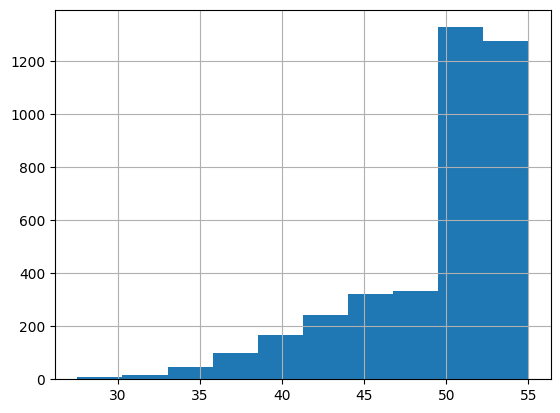

In [305]:
fichier_vote_avec_code_postal_clean[(fichier_vote_avec_code_postal_clean['voix_pct'] < 55)]['voix_pct'].hist()

In [306]:
fichier_vote_avec_code_postal_clean.to_csv("/home/onyxia/work/projet3A/data/donnees_electorales/donnees_muni_epci_completes.csv", index=False)

In [307]:
from functions import basic_functions 
#importlib.reload(BDTopo_fonctions)
#from BDTopo_fonctions import upload_to_onyxia
basic_functions.upload_to_onyxia(
    "/home/onyxia/work/projet3A/data/donnees_electorales/donnees_muni_epci_completes.csv",
    "mgarbe",
    "Elections/fichier_vote_avec_code_postal_clean.csv"
)

[Upload] Envoi de /home/onyxia/work/projet3A/data/donnees_electorales/donnees_muni_epci_completes.csv vers mgarbe/Elections/fichier_vote_avec_code_postal_clean.csv ...
[Upload] Terminé avec succès


ATTENTION !! faire ici les filtres nécessaire 

In [308]:
duel_maires_toutes_annees = (donnees_muni_wide
                    .assign(annee = lambda d : d["id_election"].str[0:4])
                    .assign(dep = lambda d : d["ident_election_ville"].str[0:2]))


duel_maires = duel_maires_toutes_annees[(duel_maires_toutes_annees['annee']!= "2008")]
duel_maires_avec_comm = pd.merge(
                            duel_maires,
                            donnees_dep_avec_nuance_pour_muni,
                            how = 'left',
                            left_on = ['annee','ident_election_ville'],
                            right_on = ['annee','insee']
                            )

duel_maires_avec_comm.drop(inplace=True, columns = ['ident_election_ville','Région siège', 'Département siège', 'Arrondissement siège',
       'Commune siège', 'N° SIREN', 'Nom du groupement', 'Nature juridique',
       'Syndicat à la carte', 'Groupement interdépartemental',
       'Date de création', "Date d'effet", 'Mode de répartition des sièges',
       'Autre mode de répartition des sièges', 'Nombre de membres',
       'Population', 'Nombre de compétences exercées', 'Mode de financement',
       'Civilité Président', 'siren', 'siren_membre',"raison_sociale", "prenom", "nom"])

In [309]:
duel_maires_avec_comm_et_code_postal_wide = pd.merge(duel_maires_avec_comm,
                                        table_code_insee_code_postal,
                                        left_on = 'insee',
                                        right_on = 'Code INSEE',
                                        how = 'inner'
                                        )                             

In [310]:
duel_maires_avec_comm_et_code_postal_wide.to_csv("/home/onyxia/work/projet3A/data/donnees_electorales/donnees_duel_maires_wide.csv", index=False)
basic_functions.upload_to_onyxia(
    "/home/onyxia/work/projet3A/data/donnees_electorales/donnees_duel_maires_wide.csv",
    "mgarbe",
    "Elections/donnees_duel_maires_wide.csv"
)

[Upload] Envoi de /home/onyxia/work/projet3A/data/donnees_electorales/donnees_duel_maires_wide.csv vers mgarbe/Elections/donnees_duel_maires_wide.csv ...
[Upload] Terminé avec succès


In [311]:
duel_maires_avec_comm_et_code_postal_wide_clean = duel_maires_avec_comm_et_code_postal_wide.rename(columns={"rang1_Prénom" : "prenom1",
"rang2_Prénom" : "prenom2", "rang1_Nom" : "Nom1", "rang2_Nom" : "Nom2", "rang1_Nuance" : "Nuance1", "rang2_Nuance" : "Nuance2", 
'rang1_voix_pct' : "voix_pct_1", 'rang2_voix_pct' : "voix_pct_2",
"Prénom Président" : "president_prenom", "Nom Président" : "president_nom"})
duel_maires_avec_comm_et_code_postal_wide_clean.columns

Index(['id_election', 'prenom1', 'prenom2', 'Nom1', 'Nom2', 'Nuance1',
       'Nuance2', 'voix_pct_1', 'voix_pct_2', 'election', 'tour', 'annee',
       'dep_x', 'president_prenom', 'president_nom', 'dep_y', 'Nuance_interco',
       'insee', 'dept', 'Code INSEE', 'Code Postal'],
      dtype='str')

In [312]:
duel_maires_avec_comm_et_code_postal_long = pd.wide_to_long(
    duel_maires_avec_comm_et_code_postal_wide_clean,
    stubnames=["Nom", "prenom","Nuance","voix_pct_"],
    i=['id_election','insee'],
    j="position"
).reset_index()

In [313]:
duel_maires_avec_comm_et_code_postal_long.to_csv("/home/onyxia/work/projet3A/data/donnees_electorales/donnees_duel_maires_long.csv", index=False)

<Axes: ylabel='Frequency'>

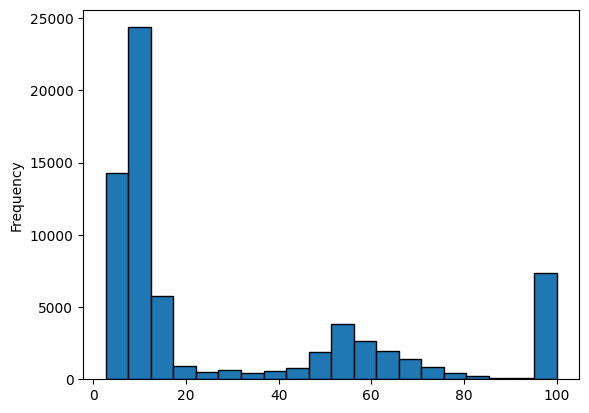

In [314]:
duel_maires_avec_comm_et_code_postal_wide_clean['voix_pct_1'].plot(kind='hist', bins=20, edgecolor='black')

In [137]:
duel_maires_avec_comm_et_code_postal_wide_clean.shape

(12263, 21)

In [139]:
duel_maires_avec_comm_et_code_postal_wide_clean[duel_maires_avec_comm_et_code_postal_wide_clean['annee'] == "2014"].shape

(9218, 21)

In [ ]:
duel_maires_avec_comm_et_code_postal_wide_clean[duel_maires_avec_comm_et_code_postal_wide_clean['annee'] == "2020"].shape

(3045, 21)

In [143]:
duel_maires_avec_comm_et_code_postal_wide_clean[duel_maires_avec_comm_et_code_postal_wide_clean['Code Postal'] == "78220"]

,id_election,prenom1,prenom2,Nom1,Nom2,Nuance1,Nuance2,voix_pct_1,voix_pct_2,election,...,annee,dep_x,president_prenom,president_nom,dep_y,Nuance_interco,insee,dept,Code INSEE,Code Postal
6586,2014_muni_t1,Olivier,Julien,LEBRUN,BOUFFARTIGUE,LUD,LSOC,60.498329,21.558797,2014_muni,...,2014,78,François,de mazieres,78,LDVD,78686,78,78686,78220
11021,2020_muni_t1,Olivier,Cécile,LEBRUN,CHOPARD,LDVD,LDVC,55.674044,22.354125,2020_muni,...,2020,78,François,de mazieres,78,LDVD,78686,78,78686,78220
